# AI-Based Financial Time Series Forecasting using LSTM

# Model Training

## Objectives

- Load processed datasets
- Load LSTM model
- Configure callbacks
- Train the model
- Save the best model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

## Load Dataset

In [2]:
X_train = np.load("../data/X_train.npy")
X_test = np.load("../data/X_test.npy")

y_train = np.load("../data/y_train.npy")
y_test = np.load("../data/y_test.npy")

## Load Model

In [3]:
model = load_model("../models/lstm_model.keras")

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 60, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 25)                1625      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 51571 (201.45 KB)
Trainable params: 51571 

## Callbacks

In [4]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../models/best_lstm_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

## Train Model

In [5]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/50
260/261 [============================>.] - ETA: 0s - loss: 4.1035e-05 - mae: 0.0031
Epoch 1: val_loss improved from inf to 0.00189, saving model to ../models\best_lstm_model.h5
261/261 [==============================] - 21s 60ms/step - loss: 4.1014e-05 - mae: 0.0031 - val_loss: 0.0019 - val_mae: 0.0246
Epoch 2/50
  3/261 [..............................] - ETA: 11s - loss: 1.8891e-05 - mae: 0.0026

c:\Users\vinit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


260/261 [============================>.] - ETA: 0s - loss: 1.1613e-05 - mae: 0.0021
Epoch 2: val_loss did not improve from 0.00189
261/261 [==============================] - 16s 62ms/step - loss: 1.1607e-05 - mae: 0.0021 - val_loss: 0.0035 - val_mae: 0.0380
Epoch 3/50
260/261 [============================>.] - ETA: 0s - loss: 1.1342e-05 - mae: 0.0021
Epoch 3: val_loss did not improve from 0.00189
261/261 [==============================] - 18s 70ms/step - loss: 1.1336e-05 - mae: 0.0021 - val_loss: 0.0030 - val_mae: 0.0325
Epoch 4/50
260/261 [============================>.] - ETA: 0s - loss: 8.8406e-06 - mae: 0.0019
Epoch 4: val_loss did not improve from 0.00189
261/261 [==============================] - 17s 66ms/step - loss: 8.8347e-06 - mae: 0.0019 - val_loss: 0.0071 - val_mae: 0.0575
Epoch 5/50
260/261 [============================>.] - ETA: 0s - loss: 7.9799e-06 - mae: 0.0018
Epoch 5: val_loss did not improve from 0.00189
261/261 [==============================] - 17s 65ms/step - los

## Save Final Model

In [6]:
model.save("../models/final_lstm_model.h5")

print("Final model saved successfully!")

Final model saved successfully!


## Plot Training Loss

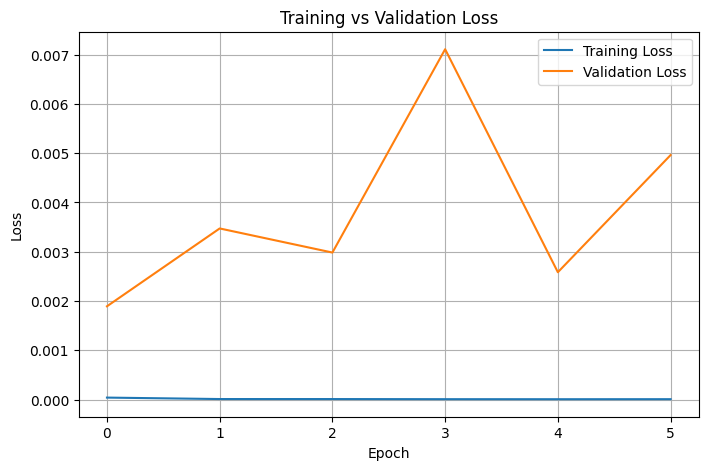

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Plot MAE

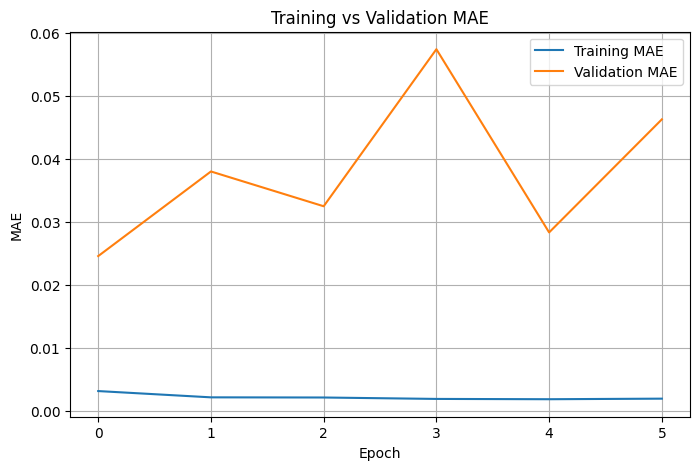

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.show()

# Summary

Completed:

- Loaded processed datasets
- Loaded LSTM model
- Configured callbacks
- Trained the model
- Saved the best model
- Saved the final model
- Visualized training performance